In [103]:
import torch
import string
from functools import partial

In [104]:
def covariant_derivative(
    field: torch.Tensor,
    k: int = 1,
    spatial_dims: list[int] = None,
) -> torch.Tensor:
    """Take k covariant derivatives of field along its spatial dimensions.

    Args:
        field: Tensor of arbitrary shape [...].
        k: Number of derivatives to take. Defaults to 1.
        spatial_dims: List containing the indices of the spatial dimensions of field,
            defaults to all dimensions. Let n = len(spatial_dims).

    Returns:
        Tensor of shape [..., n, ..., n] with k additional dimensions of size n.
    """
    B = field
    if spatial_dims is None:
        spatial_dims = list(range(field.ndim))
    for _ in range(k):
        B = torch.stack(torch.gradient(B, dim=spatial_dims), dim=-1)
    return B

grad = partial(covariant_derivative, k=1)
hessian = partial(covariant_derivative, k=2)

In [105]:
A = torch.randn(10, 8, 6)

In [106]:
def gauge_frame_hessian(
    field: torch.Tensor,
    spatial_dims: list[int] = None,
) -> torch.Tensor:
    """Compute the local gauge frame of field, the eigenvectors of its Hessian.

    Args:
        field: Tensor of arbitrary shape [...].
        spatial_dims: List containing the indices of the spatial dimensions of field,
            defaults to all dimensions. Let n = len(spatial_dims).

    Returns:
        Tensor of shape [..., n, n] with 2 additional dimensions of size n
        containing the n n-dimensional eigenvectors of the Hessian of field. 
        The [..., :, i] is the i-th frame vector.
    """
    H = hessian(field, spatial_dims=spatial_dims)
    H = (H + H.transpose(-2, -1)) / 2  # Force H symmetric (just in case)
    eigenvalues, eigenvectors = torch.linalg.eigh(H)
    return eigenvectors

def gauge_frame_hessian_squared(
    field: torch.Tensor,
    spatial_dims: list[int] = None,
) -> torch.Tensor:
    """Compute the local gauge frame of field, the eigenvectors of its Hessian Squared.

    Args:
        field: Tensor of arbitrary shape [...].
        spatial_dims: List containing the indices of the spatial dimensions of field,
            defaults to all dimensions. Let n = len(spatial_dims).

    Returns:
        Tensor of shape [..., n, n] with 2 additional dimensions of size n
        containing the n n-dimensional eigenvectors of the Hessian of field. 
        The [..., :, i] is the i-th frame vector.
    """
    H = hessian(field, spatial_dims=spatial_dims)
    H2 = H @ H
    eigenvalues, eigenvectors = torch.linalg.eigh(H2)
    return eigenvectors

def gauge_frame_structure_tensor(
    field: torch.Tensor,
    spatial_dims: list[int] = None,
) -> torch.Tensor:
    """Compute the local gauge frame of field, the eigenvectors of its structure tensor.

    Args:
        field: Tensor of arbitrary shape [...].
        spatial_dims: List containing the indices of the spatial dimensions of field,
            defaults to all dimensions. Let n = len(spatial_dims).

    Returns:
        Tensor of shape [..., n, n] with 2 additional dimensions of size n
        containing the n n-dimensional eigenvectors of the structure tensor of field.
        The [..., :, i] is the i-th frame vector.
    """
    G = grad(field, spatial_dims=spatial_dims)
    G2 = G[..., :, None] @ G[..., None, :]
    eigenvalues, eigenvectors = torch.linalg.eigh(G2)
    return eigenvectors

In [107]:
def gauge_derivative(
    field: torch.Tensor,
    frame: torch.Tensor,
    signature: list[int],
    spatial_dims: list[int] = None,
) -> torch.Tensor:
    """Take the gauge derivative of field with signature `signature`

    Args:
        field: Tensor of arbitrary shape [...].
        frame: Tensor of shape [..., n, n] specifying the gauge frame.
        signature: Signature of the gauge derivative, a list of k=len(signature) 
            integers where each integer is in the range [0, n-1].
        spatial_dims: List containing the indices of the spatial dimensions of field,
            defaults to all dimensions. Let n = len(spatial_dims).

    Returns:
        Tensor of shape [...].
    """
    k = len(signature)
    deriv = covariant_derivative(field, k=k, spatial_dims=spatial_dims) 
    letters = string.ascii_letters[:k]                               
    equation = ",".join(["..." + letters] + ["..." + c for c in letters]) + "->..."
    # print(equation)
    return torch.einsum(equation, deriv, *(frame[..., :, i] for i in signature))

In [108]:
def gaussian_blur(
    field: torch.Tensor,
    sigma: float,
) -> torch.Tensor:
    """Blur a 2D tensor with an isotropic Gaussian, separably.

    Derivatives of raw pixel data are dominated by noise, so the image is smoothed
    before its gauge frame and gauge derivatives are computed.

    Args:
        A: Tensor of shape [H, W].
        sigma: Standard deviation of the Gaussian, in pixels.

    Returns:
        Tensor of shape [H, W].
    """
    r = int(3 * sigma)
    x = torch.arange(-r, r + 1, dtype=field.dtype)
    k = torch.exp(-(x**2) / (2 * sigma**2))
    k = k / k.sum()
    field = torch.nn.functional.conv2d(field[None, None], k.view(1, 1, -1, 1), padding=(r, 0))
    field = torch.nn.functional.conv2d(field, k.view(1, 1, 1, -1), padding=(0, r))
    return field[0, 0]

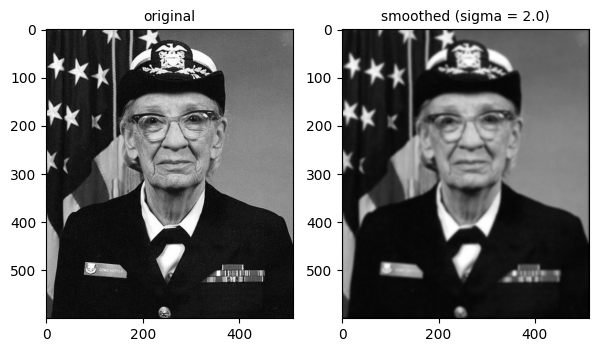

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

sigma = 2.0
with cbook.get_sample_data("grace_hopper.jpg") as f:
    image = torch.tensor(np.asarray(Image.open(f).convert("L"), dtype=np.float32) / 255)
blurred = gaussian_blur(image, sigma=sigma)

fig, axes = plt.subplots(1, 2, figsize=(7, 4))
for ax, a, title in zip(axes, (image, blurred), ("original", f"smoothed (sigma = {sigma})")):
    ax.imshow(a, cmap="gray")
    ax.set_title(title, fontsize=10)

In [120]:
frame = gauge_frame_structure_tensor(blurred)

In [118]:
FRAME_COLORS = ("#2a78d6", "#eb6834")
def show_gauge_frame(frame, ax, r0, r1, c0, c1, step):
    """Draw the gauge frame over rows r0:r1 and columns c0:c1, every step-th pixel, onto ax."""
    ax.imshow(blurred[r0:r1, c0:c1], cmap="gray", extent=(c0, c1, r1, r0))
    ys, xs = np.mgrid[r0:r1:step, c0:c1:step]
    for i, color in enumerate(FRAME_COLORS):
        v = frame[r0:r1:step, c0:c1:step, :, i]
        ax.quiver(
            xs, ys, 
            v[..., 1], v[..., 0], 
            color=color, pivot="mid",
            headwidth=0, headlength=0, headaxislength=0, 
            scale=40, width=0.004
        )

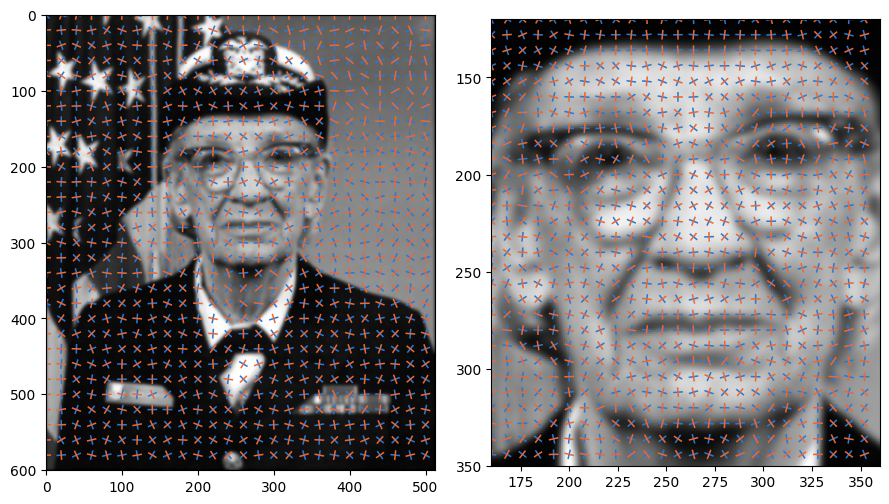

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5.5))
show_gauge_frame(frame, axes[0], 0, blurred.shape[0], 0, blurred.shape[1], 20)
show_gauge_frame(frame, axes[1], 120, 350, 160, 360, 8)
fig.tight_layout()

In [113]:
DIVERGING = LinearSegmentedColormap.from_list("blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"])
def show_gauge_derivative(ax, signature):
    """Draw the gauge derivative of blurred with the given signature onto ax."""
    field = gauge_derivative(blurred, frame, signature)
    ax.imshow(field, cmap=DIVERGING, vmin=-0.1, vmax=0.1)
    ax.set_title(f"signature {signature}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

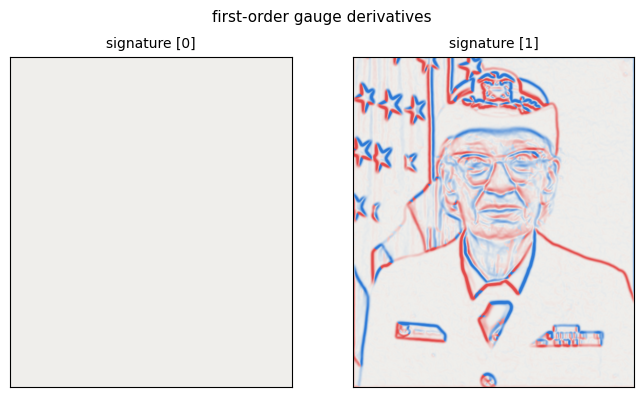

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4))
for ax, signature in zip(axes, ([0], [1])):
    show_gauge_derivative(ax, signature)
fig.suptitle("first-order gauge derivatives", fontsize=11)
fig.tight_layout()

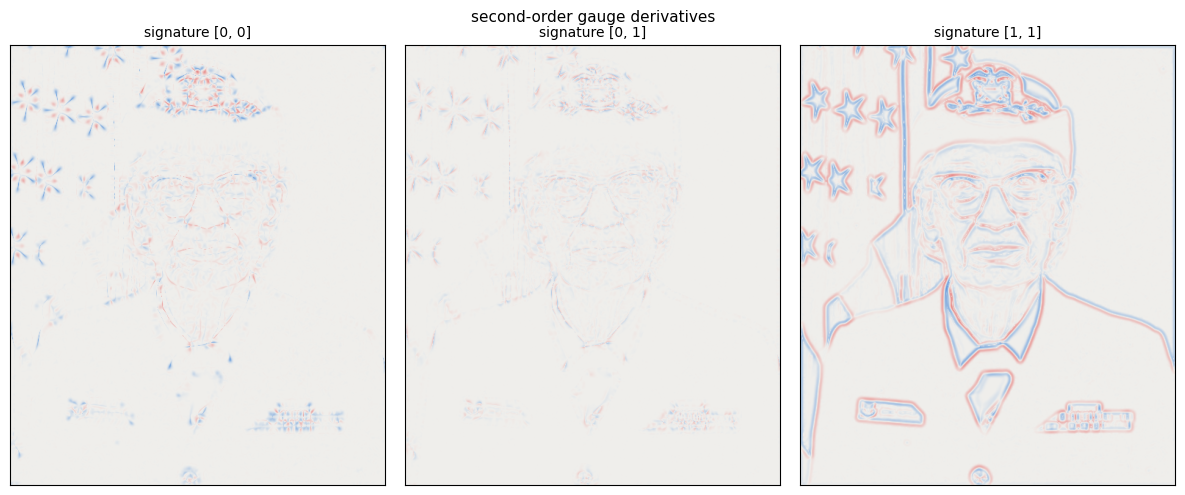

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, signature in zip(axes.flat, ([0, 0], [0, 1], [1, 1])):
    show_gauge_derivative(ax, signature)
fig.suptitle("second-order gauge derivatives", fontsize=11)
fig.tight_layout()

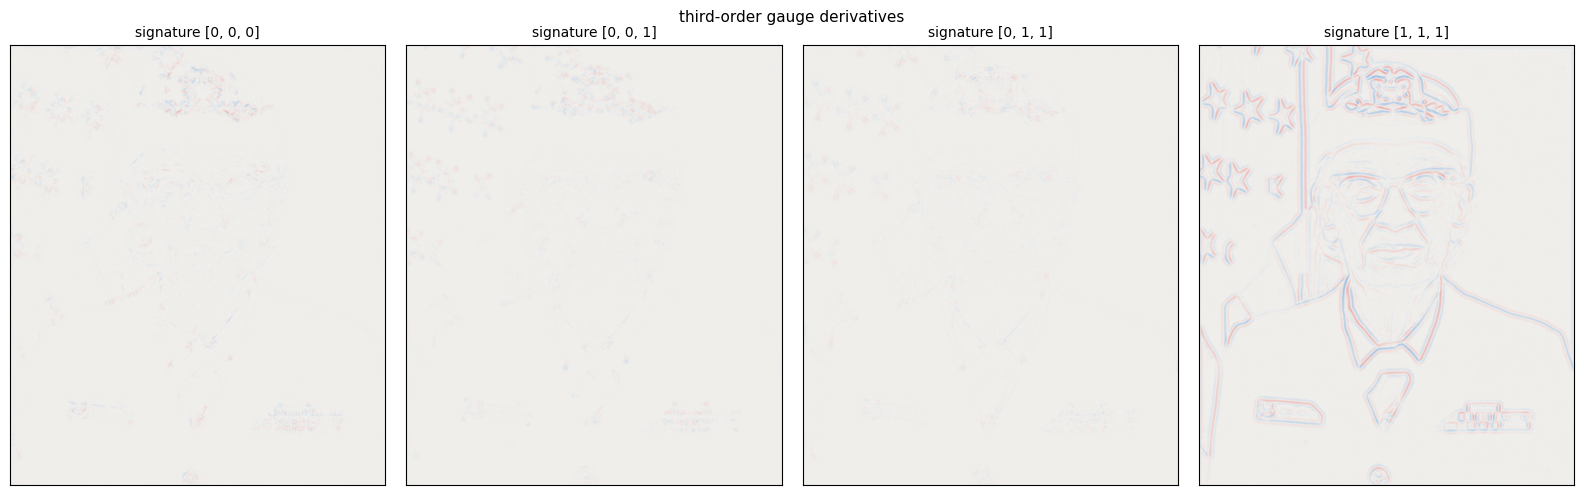

In [116]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, signature in zip(axes.flat, ([0, 0, 0], [0, 0, 1], [0, 1, 1], [1, 1, 1])):
    show_gauge_derivative(ax, signature)
fig.suptitle("third-order gauge derivatives", fontsize=11)
fig.tight_layout()